In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from lib.iux001 import fetch_data, aggregation_data,merging_data1
from lib.aux001 import calc_expression
from lib.cux001 import FactorEvaluate1 as FactorEvaluate1

In [3]:
method = 'bicso2'
instruments = 'rbb'
period = 5
task_id = '113001'
datasets = ['train','val']

In [4]:
bench_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/bicso2/rbb/basic/train_data.feather
./records/bicso2/rbb/basic/val_data.feather
./records/bicso2/rbb/returns/train_returns.feather
./records/bicso2/rbb/returns/val_returns.feather


In [5]:
method = 'bicso3'
instruments = 'rbb'
period = 5
task_id = '113001'
datasets = ['train','val']

In [6]:
rearch_data = fetch_data(method=method,
                        instruments=instruments,
                        task_id=task_id,
                        datasets=datasets)

./records/bicso3/rbb/basic/train_data.feather
./records/bicso3/rbb/basic/val_data.feather
./records/bicso3/rbb/returns/train_returns.feather
./records/bicso3/rbb/returns/val_returns.feather


In [7]:
cols = ['nxt1_ret_1h','nxt1_ret_2h',
        'nxt1_ret_3h','nxt1_ret_5h','nxt1_ret_10h']
bench_data1 = bench_data[['trade_time','code'] + cols].set_index(
    ['trade_time','code']).unstack().shift(-1).stack().reset_index()

In [8]:
bench_data1

,trade_time,code,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h
0,2011-01-04 09:17:00,RB,-0.000025,-0.000100,-0.000015,-0.000253,-0.000006
1,2011-01-04 09:18:00,RB,-0.000075,0.000010,-0.000175,0.000058,-0.000174
2,2011-01-04 09:19:00,RB,0.000085,-0.000100,-0.000153,0.000394,-0.000272
3,2011-01-04 09:20:00,RB,-0.000185,-0.000238,0.000049,0.000529,-0.000373
4,2011-01-04 09:21:00,RB,-0.000053,0.000233,0.000494,0.000498,-0.000145
...,...,...,...,...,...,...,...
1010068,2024-02-21 09:49:00,RB,0.000251,0.000444,0.000041,-0.000694,-0.000159
1010069,2024-02-21 09:50:00,RB,0.000193,-0.000210,-0.000994,-0.000477,0.000071
1010070,2024-02-21 09:51:00,RB,-0.000403,-0.001187,-0.001139,-0.000485,0.000052
1010071,2024-02-21 09:52:00,RB,-0.000784,-0.000736,-0.000268,-0.000403,0.000468


In [9]:
cols = ['trade_time','code','iv012_1_2_1']
rearch_data1 = rearch_data[cols]

In [10]:
total_data1 = bench_data1.merge(rearch_data1, on=['trade_time','code']).sort_values(
    by=['trade_time','code'])

In [11]:
total_data2 = total_data1[[
    'trade_time','code','iv012_1_2_1','nxt1_ret_{0}h'.format(period)]]#.loc[1000:]

total_data2[total_data2['trade_time'] >= '2020-01-01 09:03:00']

,trade_time,code,iv012_1_2_1,nxt1_ret_5h
635953,2020-01-02 09:01:00,RB,-0.002579,-0.002000
635954,2020-01-02 09:02:00,RB,-0.001017,-0.002971
635955,2020-01-02 09:03:00,RB,-0.000539,-0.002730
635956,2020-01-02 09:04:00,RB,0.000009,-0.001950
635957,2020-01-02 09:05:00,RB,0.000862,-0.000156
...,...,...,...,...
950504,2024-02-21 09:49:00,RB,-0.000084,-0.000694
950505,2024-02-21 09:50:00,RB,-0.000451,-0.000477
950506,2024-02-21 09:51:00,RB,-0.000512,-0.000485
950507,2024-02-21 09:52:00,RB,-0.000042,-0.000403


In [12]:
#expression = "MRANK(240,MRANK(240,'tc003_2_3_1'))"
expression = "MA(10,'iv012_1_2_1')"

In [13]:
total_data1

,trade_time,code,nxt1_ret_1h,nxt1_ret_2h,nxt1_ret_3h,nxt1_ret_5h,nxt1_ret_10h,iv012_1_2_1
0,2011-02-01 09:03:00,RB,0.000402,0.000500,-0.000050,-0.000608,-0.001203,-0.000652
1,2011-02-01 09:04:00,RB,0.000098,-0.000452,-0.001185,-0.001279,-0.001665,-0.000252
2,2011-02-01 09:05:00,RB,-0.000549,-0.001283,-0.001108,-0.001679,-0.001994,-0.000526
3,2011-02-01 09:06:00,RB,-0.000734,-0.000559,-0.000827,-0.001636,-0.001663,0.000101
4,2011-02-01 09:07:00,RB,0.000175,-0.000093,-0.000396,-0.000764,-0.000380,0.000594
...,...,...,...,...,...,...,...,...
950504,2024-02-21 09:49:00,RB,0.000251,0.000444,0.000041,-0.000694,-0.000159,-0.000084
950505,2024-02-21 09:50:00,RB,0.000193,-0.000210,-0.000994,-0.000477,0.000071,-0.000451
950506,2024-02-21 09:51:00,RB,-0.000403,-0.001187,-0.001139,-0.000485,0.000052,-0.000512
950507,2024-02-21 09:52:00,RB,-0.000784,-0.000736,-0.000268,-0.000403,0.000468,-0.000042


In [14]:
%%time
factor_data1 = calc_expression(expression=expression,
                              total_data=total_data1[['trade_time','code','iv012_1_2_1']].set_index('trade_time'))

CPU times: user 18.1 s, sys: 683 ms, total: 18.8 s
Wall time: 18.8 s


In [15]:
dt = merging_data1(factor_data=factor_data1,
                      returns_data=total_data1,
                      period=period)

In [16]:
dt.tail(10)

,trade_time,transformed,code,nxt1_ret_5h
950498,2024-02-21 09:44:00,-0.000188,RB,0.001444
950499,2024-02-21 09:45:00,-0.000149,RB,0.001238
950500,2024-02-21 09:46:00,-0.000162,RB,0.001582
950501,2024-02-21 09:47:00,-0.000162,RB,0.000668
950502,2024-02-21 09:48:00,-0.000243,RB,-0.000270
950503,2024-02-21 09:49:00,-0.000212,RB,-0.000694
950504,2024-02-21 09:50:00,-0.000206,RB,-0.000477
950505,2024-02-21 09:51:00,-0.000184,RB,-0.000485
950506,2024-02-21 09:52:00,-0.000174,RB,-0.000403
950507,2024-02-21 09:53:00,-0.000149,RB,0.000285


In [17]:
evaluate1 = FactorEvaluate1(factor_data=dt,
                                factor_name='transformed',
                                ret_name='nxt1_ret_{0}h'.format(period),
                                roll_win=15,
                                fee=0.0,
                                scale_method='roll_zscore',
                                expression=expression,
                                resampling_win=period)

In [18]:
stats_dt = evaluate1.run()

In [19]:
stats_dt

{'total_ret': 59.6677744898296,
 'avg_ret': 2.1830772721136663e-05,
 'max_dd': -0.08346691835308762,
 'calmar': 2.877578483314421,
 'sharpe1': 0.027310232030710875,
 'sharpe2': 2.8528560061055033,
 'turnover': 0.43144121196857194,
 'win_rate': 0.519553804399082,
 'profit_ratio': 1.110690340730969,
 'total_ic': 0.02863408979868119,
 'ic_mean': 0.056587614719506636,
 'ic_std': 0.26095022694790254,
 'ic_ir': 0.21685213836125186,
 'factor_autocorr': 0.5641608287164339,
 'ret_autocorr': 0.01221624423916363}

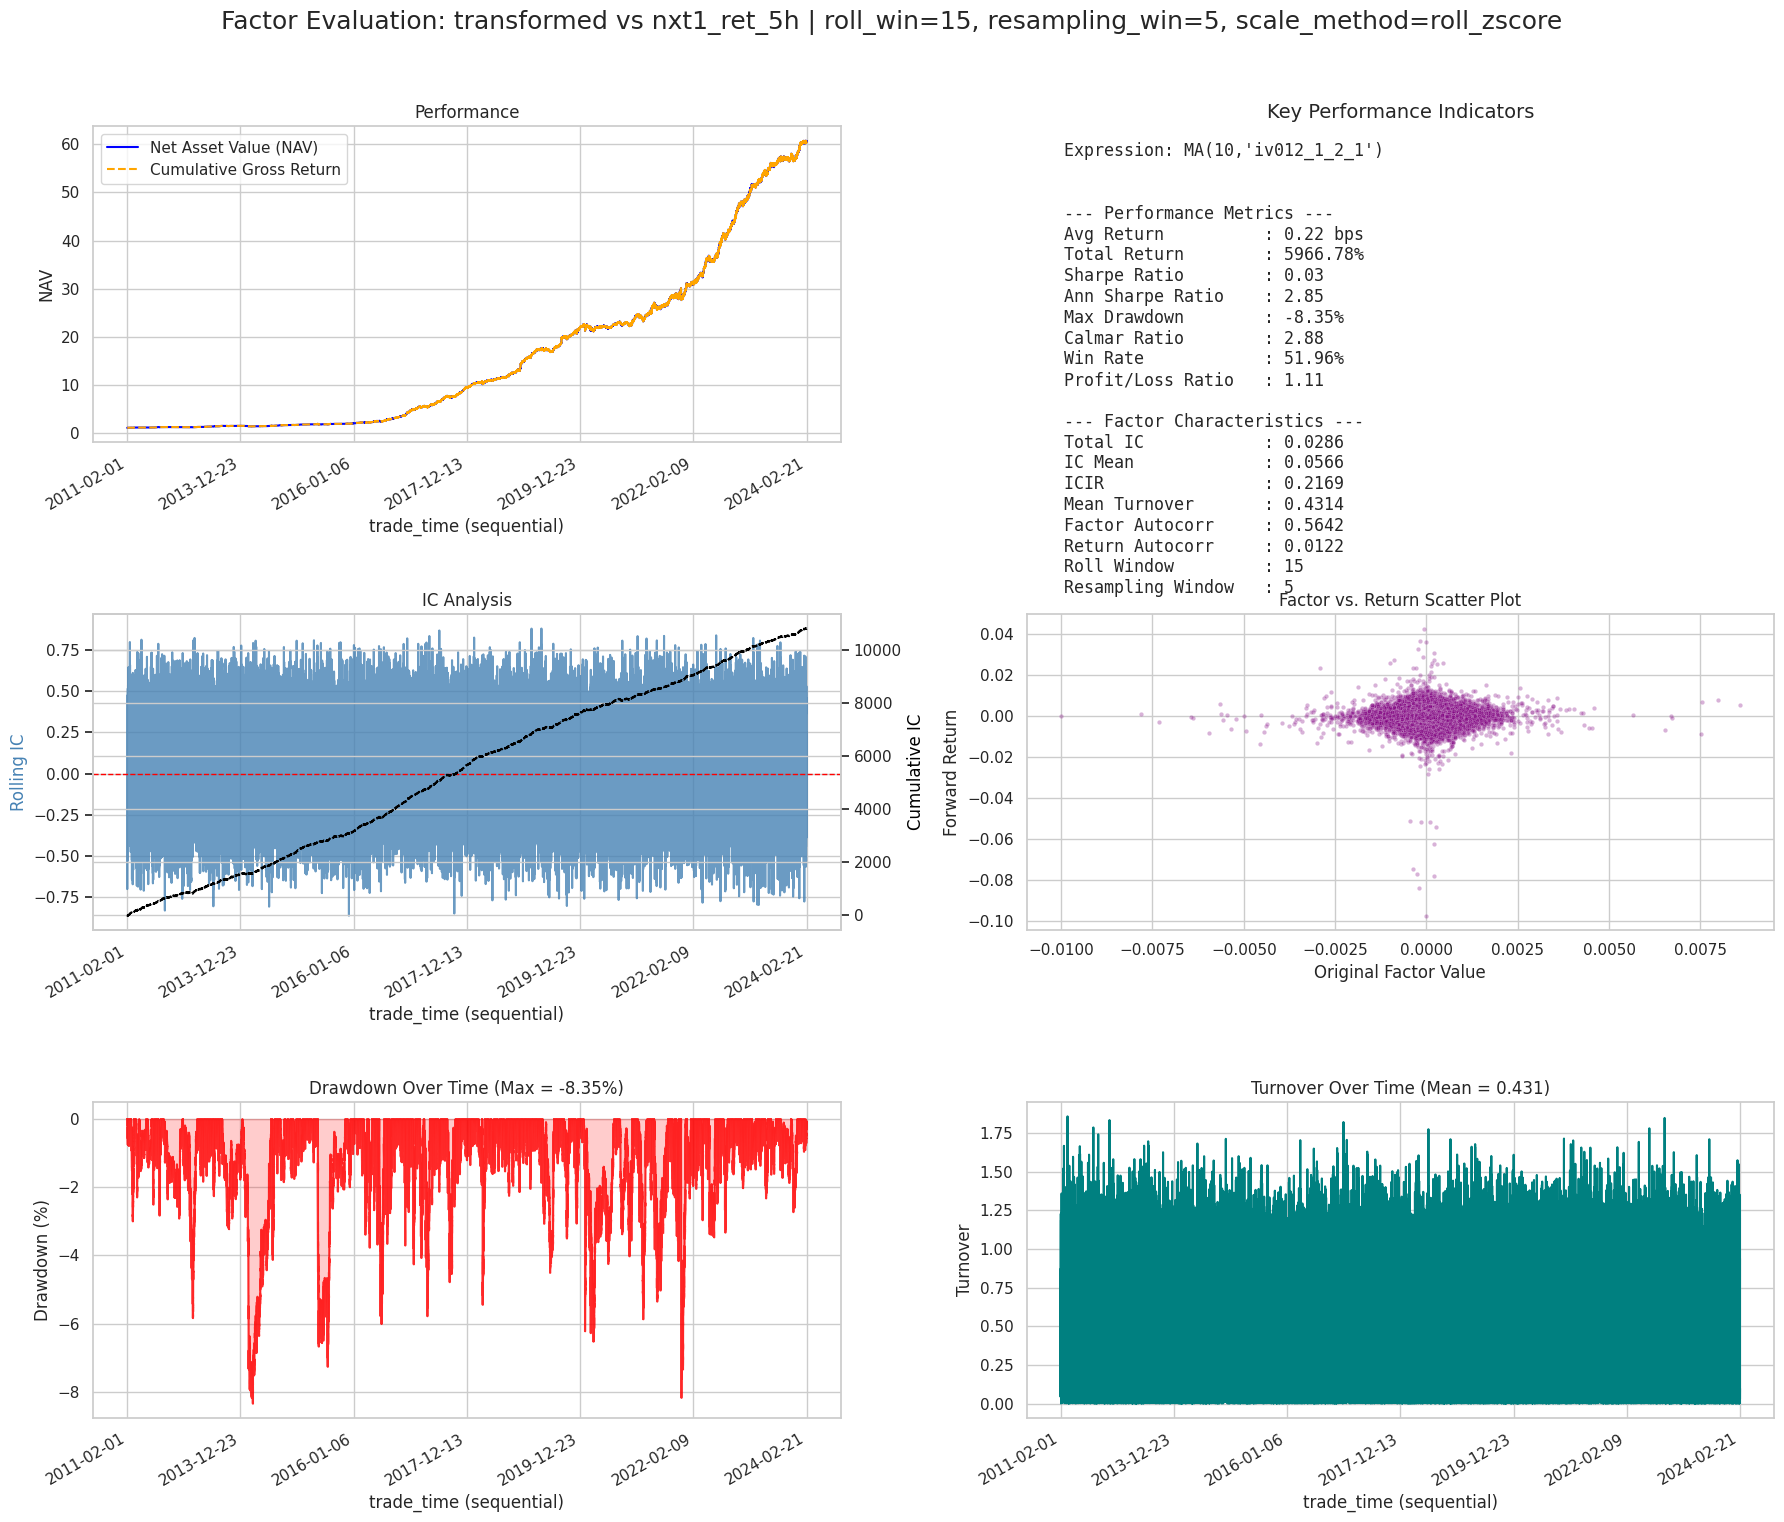

In [20]:
evaluate1.plot_results()